# Testy metod augmentacji danych dla klasyfikacji znaków drogowych

Celem eksperymentu jest określenie wpływu różnych rodzajów augmentacji danych treningowych na skuteczność klasyfikacji znaków drogowych z wykorzystaniem modelu ResNet50.

Wszystkie konfiguracje wykorzystują:

- tę samą architekturę `ResNet50`,
- wagi ImageNet,
- strategię `WeightedRandomSampler`,
- ten sam podział danych,
- identyczne parametry optymalizacji.

Zmiennym elementem eksperymentu jest wyłącznie rodzaj augmentacji stosowanej podczas treningu.

Porównane zostaną augmentacje geometryczne, fotometryczne oraz związane z degradacją jakości obrazu.

Etap ma charakter przesiewowy. Do porównania konfiguracji wykorzystano skrócony proces uczenia obejmujący trening przy zamrożonym backbone oraz krótki fine-tuning.

Podstawowym kryterium oceny jest `Macro F1` uzyskany na zbiorze walidacyjnym.

Zbiór `test_final` nie jest wykorzystywany do wyboru konfiguracji.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "augmentation_screening"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 5
FINE_TUNE_EPOCHS = 2
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True

CONFIGURATIONS = [
    {
        "name": "baseline",
        "augmentation": "baseline",
    },

    {
        "name": "geometric",
        "augmentation": "geometric",
    },

    {
        "name": "photometric",
        "augmentation": "photometric",
    },

    {
        "name": "blur_noise",
        "augmentation": "blur_noise",
    },

    {
        "name": "combined",
        "augmentation": "combined",
    },
]


print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:
    print(
        configuration
    )

Konfiguracje:
{'name': 'baseline', 'augmentation': 'baseline'}
{'name': 'geometric', 'augmentation': 'geometric'}
{'name': 'photometric', 'augmentation': 'photometric'}
{'name': 'blur_noise', 'augmentation': 'blur_noise'}
{'name': 'combined', 'augmentation': 'combined'}


## 2. Manifesty danych i mapowanie klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Definicja szumu gaussowskiego

Dodanie niewielkiego szumu gaussowskiego służy symulacji pogorszenia jakości obrazu występującego podczas rejestracji obrazu przez system wizyjny.

In [4]:
class AddGaussianNoise:

    def __init__(
        self,
        mean=0.0,
        std=0.03,
    ):

        self.mean = mean
        self.std = std


    def __call__(
        self,
        tensor,
    ):

        noise = torch.randn_like(
            tensor
        ) * self.std + self.mean


        tensor = tensor + noise


        return torch.clamp(
            tensor,
            0.0,
            1.0,
        )

## 4. Transformacje bazowe i warianty augmentacji

W każdej konfiguracji zachowane zostają te same operacje przygotowania obrazu.

Bazowa konfiguracja obejmuje zmianę rozmiaru obrazu, niewielką rotację oraz normalizację.

Pozostałe konfiguracje rozszerzają ten zestaw o jeden określony rodzaj augmentacji lub ich kontrolowane połączenie.

In [5]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_augmentation_transform(
    augmentation,
):

    transform_list = [
        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
        ),

        transforms.RandomRotation(
            10
        ),
    ]


    if augmentation == "geometric":

        transform_list.extend(
            [
                transforms.RandomAffine(
                    degrees=0,
                    translate=(
                        0.05,
                        0.05,
                    ),
                    scale=(
                        0.95,
                        1.05,
                    ),
                ),
            ]
        )


    elif augmentation == "photometric":

        transform_list.extend(
            [
                transforms.ColorJitter(
                    brightness=0.20,
                    contrast=0.20,
                    saturation=0.10,
                    hue=0.02,
                ),
            ]
        )


    elif augmentation == "blur_noise":

        transform_list.extend(
            [
                transforms.RandomApply(
                    [
                        transforms.GaussianBlur(
                            kernel_size=3,
                            sigma=(
                                0.1,
                                1.0,
                            ),
                        )
                    ],
                    p=0.30,
                ),
            ]
        )


    elif augmentation == "combined":

        transform_list.extend(
            [
                transforms.RandomAffine(
                    degrees=0,
                    translate=(
                        0.05,
                        0.05,
                    ),
                    scale=(
                        0.95,
                        1.05,
                    ),
                ),

                transforms.ColorJitter(
                    brightness=0.20,
                    contrast=0.20,
                    saturation=0.10,
                    hue=0.02,
                ),

                transforms.RandomApply(
                    [
                        transforms.GaussianBlur(
                            kernel_size=3,
                            sigma=(
                                0.1,
                                1.0,
                            ),
                        )
                    ],
                    p=0.20,
                ),
            ]
        )


    elif augmentation == "baseline":

        pass


    else:

        raise ValueError(
            f"Nieznany wariant augmentacji: "
            f"{augmentation}"
        )


    transform_list.append(
    transforms.ToTensor()
)


    if augmentation in [
        "blur_noise",
        "combined",
    ]:

        transform_list.append(
            AddGaussianNoise(
                mean=0.0,
                std=0.01,
            )
        )


    transform_list.append(
        normalization
    )


    return transforms.Compose(
        transform_list
    )

## 5. Transformacja ewaluacyjna

Podczas walidacji nie są stosowane losowe augmentacje.

Każdy model oceniany jest na tych samych, niezmodyfikowanych obrazach walidacyjnych oraz na identycznych kontrolowanych wariantach oświetleniowych.

In [6]:
def build_evaluation_transform():

    return transforms.Compose(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 6. Wizualizacja wariantów augmentacji

Przed rozpoczęciem treningu przedstawiono przykładowe realizacje poszczególnych wariantów augmentacji.

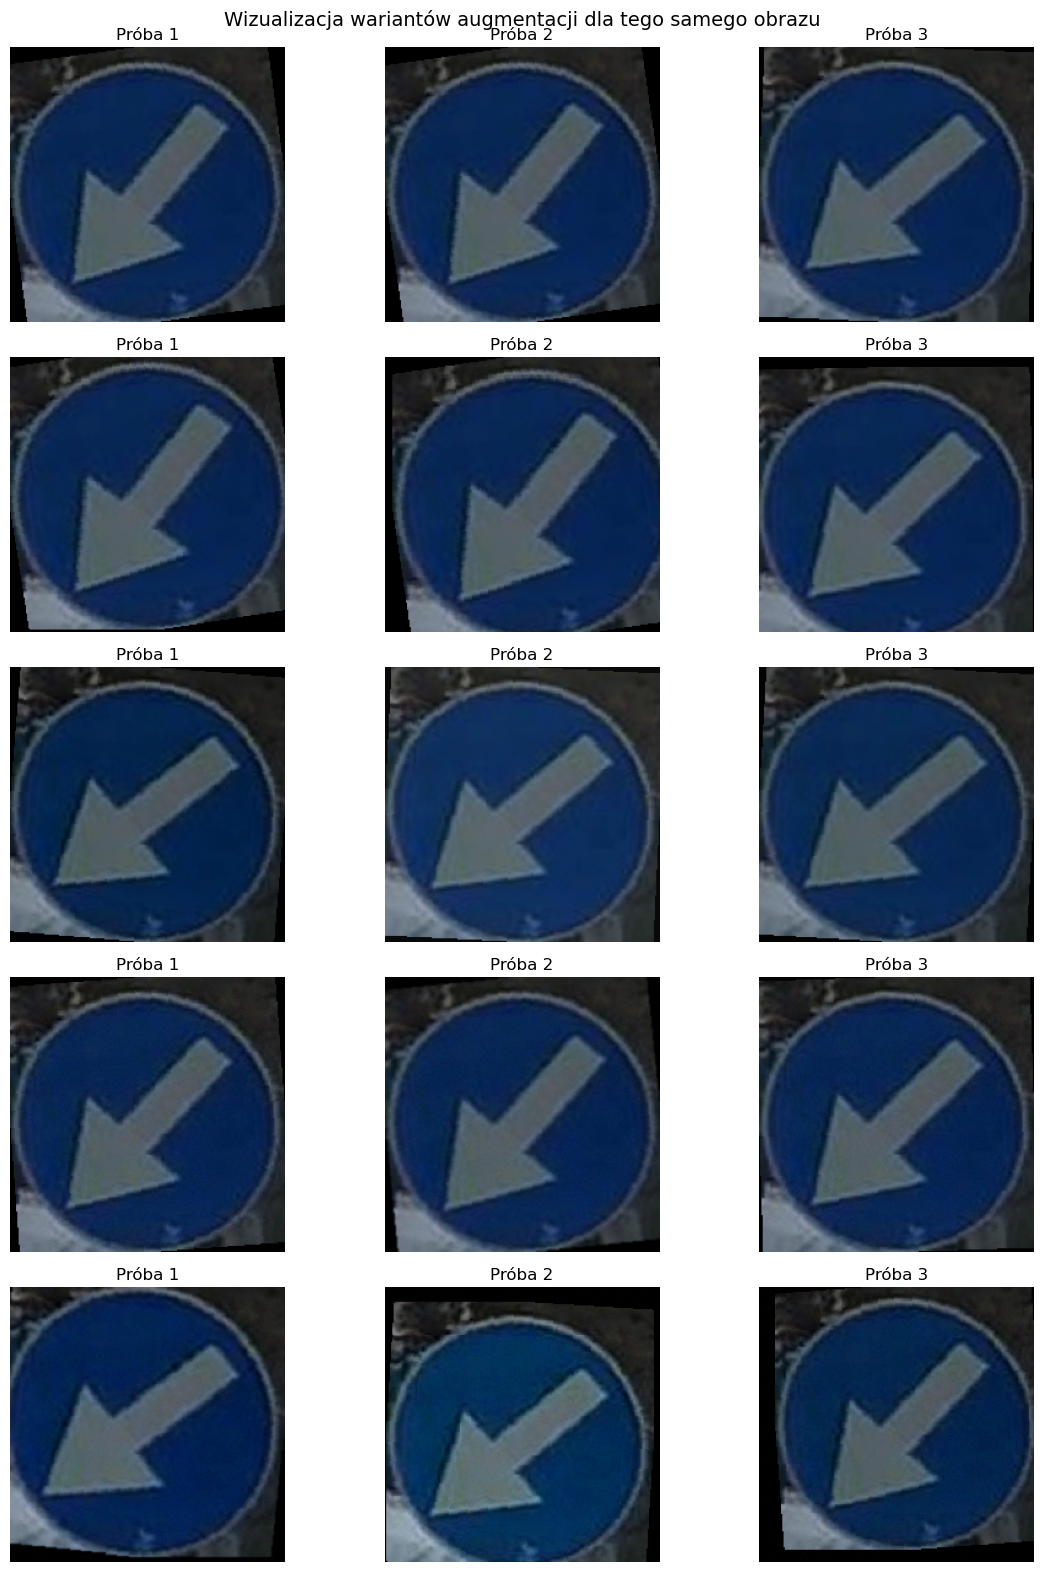

In [7]:
from PIL import Image
import numpy as np


sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


def apply_augmentation_for_display(
    image,
    augmentation,
):

    transform = (
        build_augmentation_transform(
            augmentation
        )
    )


    result = image


    for step in transform.transforms:

        if isinstance(
            step,
            transforms.ToTensor,
        ):
            break


        if isinstance(
            step,
            transforms.Normalize,
        ):
            break


        if isinstance(
            step,
            AddGaussianNoise,
        ):
            continue


        result = step(
            result
        )


    # Wizualizacja lekkiego szumu
    if augmentation in [
        "blur_noise",
        "combined",
    ]:

        array = np.asarray(
            result,
            dtype=np.float32,
        ) / 255.0


        noise = (
            np.random.normal(
                0.0,
                0.01,
                array.shape,
            )
        )


        array = np.clip(
            array + noise,
            0.0,
            1.0,
        )


        result = Image.fromarray(
            (
                array * 255
            ).astype(
                np.uint8
            )
        )


    return result


fig, axes = plt.subplots(
    len(CONFIGURATIONS),
    3,
    figsize=(12, 16),
)


if len(CONFIGURATIONS) == 1:

    axes = np.array(
        [axes]
    )


for row_index, configuration in enumerate(
    CONFIGURATIONS
):

    augmentation = (
        configuration[
            "augmentation"
        ]
    )


    for col_index in range(3):

        augmented_image = (
            apply_augmentation_for_display(
                sample_image,
                augmentation,
            )
        )


        axes[
            row_index,
            col_index
        ].imshow(
            augmented_image
        )


        if col_index == 0:

            axes[
                row_index,
                col_index
            ].set_ylabel(
                configuration[
                    "name"
                ],
                fontsize=11,
            )


        axes[
            row_index,
            col_index
        ].set_title(
            f"Próba {col_index + 1}"
        )


        axes[
            row_index,
            col_index
        ].axis(
            "off"
        )


axes[
    0,
    0
].set_title(
    "Próba 1"
)


fig.suptitle(
    "Wizualizacja wariantów augmentacji "
    "dla tego samego obrazu",
    fontsize=14,
)


plt.tight_layout()
plt.show()

## 7. Przygotowanie DataLoaderów

In [8]:
def build_loaders(
    augmentation,
):

    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=(
                build_augmentation_transform(
                    augmentation
                )
            ),
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 8. Przygotowanie modelu ResNet50

In [9]:
def create_model():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    return model

## 9. Trening konfiguracji

Każda konfiguracja jest trenowana przy wykorzystaniu identycznej procedury.

Zmieniany jest wyłącznie wariant augmentacji danych treningowych.

In [10]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]

    augmentation = configuration[
        "augmentation"
    ]


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        f"Augmentation: {augmentation}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_loaders(
        augmentation
    )


    model = create_model()


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"augmentation_screening_"
            f"{name}_frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"augmentation_screening_"
            f"{name}_finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration":
            configuration,

        "model":
            model,

        "validation_loader":
            validation_loader,

        "train_loader":
            train_loader,

        "frozen_history":
            frozen_history,

        "finetune_history":
            finetune_history,
    }

## 10. Trening screeningu

In [11]:
experiments = {}


for configuration in CONFIGURATIONS:

    result = train_configuration(
        configuration
    )


    experiments[
        configuration["name"]
    ] = result


print(
    "\nScreening zakończony."
)


Konfiguracja: baseline
Augmentation: baseline


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu:   0%|          | 0/2 [00:00<?, ?it/s]

Epoka 1/2:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/2:   0%|          | 0/445 [00:00<?, ?it/s]


Screening zakończony.


## 11. Ocena standardowej klasyfikacji na zbiorze walidacyjnym

In [12]:
standard_results = []


for name, experiment in (
    experiments.items()
):

    y_true, y_pred, inference_time = (
        predict(
            experiment[
                "model"
            ],
            experiment[
                "validation_loader"
            ],
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    standard_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)


display(
    standard_validation_df
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
2,photometric,0.890127,0.893962,0.905845,0.894604,183.794026
0,baseline,0.895701,0.882199,0.903555,0.887332,188.845092
1,geometric,0.883360,0.881253,0.905110,0.885015,187.360583
3,blur_noise,0.802548,0.793023,0.766221,0.743412,190.039978
4,combined,0.763535,0.727864,0.754753,0.700939,195.680304


## 12. Funkcja oceny kontrolowanych warunków oświetleniowych

In [15]:
from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

def evaluate_lighting_variant(
    model,
    variant,
):

    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_evaluation_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 13. Ocena odporności na zaciemnienie

Każda konfiguracja jest oceniana na trzech kontrolowanych poziomach zaciemnienia.

Jako główny wskaźnik odporności przyjęto średnią wartość `Macro F1` dla `dark_1`, `dark_2` i `dark_3`.

In [16]:
dark_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]


    for variant in [
        "dark_1",
        "dark_2",
        "dark_3",
    ]:

        print(
            f"{name} | {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model,
                variant,
            )
        )


        dark_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


dark_results_df = pd.DataFrame(
    dark_results
)


display(
    dark_results_df
)

baseline | dark_1
baseline | dark_2
baseline | dark_3
geometric | dark_1
geometric | dark_2
geometric | dark_3
photometric | dark_1
photometric | dark_2
photometric | dark_3
blur_noise | dark_1
blur_noise | dark_2
blur_noise | dark_3
combined | dark_1
combined | dark_2
combined | dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,baseline,dark_1,0.7,2512,0.887739,0.875206,0.897674,0.878820,225.434614
1,baseline,dark_2,0.5,2512,0.872611,0.850638,0.855883,0.842603,198.907123
2,baseline,dark_3,0.3,2512,0.843153,0.819536,0.844606,0.816983,203.773495
3,geometric,dark_1,0.7,2512,0.874204,0.875324,0.890374,0.873787,205.126352
4,geometric,dark_2,0.5,2512,0.858678,0.847151,0.865985,0.843892,200.670934
5,geometric,dark_3,0.3,2512,0.825239,0.813287,0.845666,0.810654,207.042911
6,photometric,dark_1,0.7,2512,0.887341,0.880720,0.886980,0.876151,239.449395
7,photometric,dark_2,0.5,2512,0.880971,0.876467,0.886218,0.871104,215.393613
8,photometric,dark_3,0.3,2512,0.848726,0.838652,0.868251,0.842308,213.324445
9,blur_noise,dark_1,0.7,2512,0.794188,0.785026,0.765972,0.744320,216.481446


## 14. Podsumowanie odporności

In [17]:
dark_summary = (
    dark_results_df
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


dark3_summary = (
    dark_results_df[
        dark_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard_summary = (
    standard_validation_df[
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


robustness_summary = (
    dark_summary
    .join(
        dark3_summary
    )
    .join(
        standard_summary
    )
)


robustness_summary[
    "f1_drop_to_dark3"
] = (
    robustness_summary[
        "standard_macro_f1"
    ]
    -
    robustness_summary[
        "dark3_macro_f1"
    ]
)


robustness_summary = (
    robustness_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    robustness_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
photometric,0.863188,0.872346,0.842308,0.894604,0.052296
baseline,0.846135,0.867834,0.816983,0.887332,0.070349
geometric,0.842778,0.852707,0.810654,0.885015,0.074361
blur_noise,0.706654,0.759554,0.654840,0.743412,0.088572
combined,0.620982,0.685377,0.539024,0.700939,0.161915


## 15. Porównanie wariantów augmentacji

configuration,baseline,blur_noise,combined,geometric,photometric
variant,,,,,
dark_1,0.878820,0.744320,0.679823,0.873787,0.876151
dark_2,0.842603,0.720801,0.644100,0.843892,0.871104
dark_3,0.816983,0.654840,0.539024,0.810654,0.842308


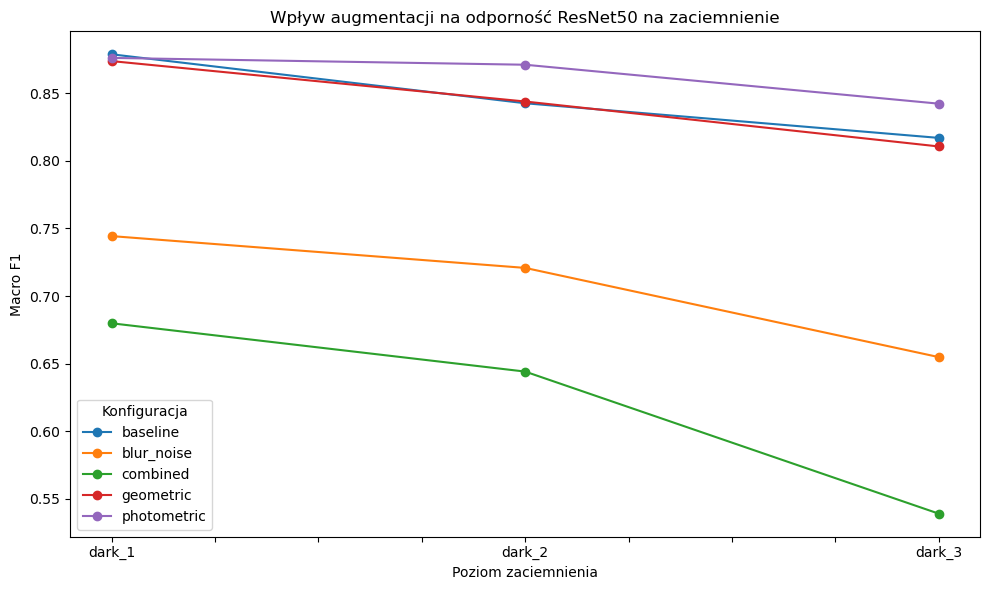

In [18]:
dark_plot = (
    dark_results_df
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        [
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Wpływ augmentacji na odporność "
    "ResNet50 na zaciemnienie"
)

ax.set_xlabel(
    "Poziom zaciemnienia"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_augmentation_screening_dark_f1.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 16. Wybór kandydatów do pełnego treningu

Na podstawie wyników screeningu wybrana zostanie jedna lub maksymalnie dwie konfiguracje o najwyższej wartości `mean_dark_macro_f1`.

Screening służy wyłącznie do redukcji liczby konfiguracji poddawanych pełnemu treningowi.

In [19]:
BEST_SCREENING_CANDIDATES = (
    robustness_summary
    .head(2)
)


display(
    BEST_SCREENING_CANDIDATES
)


print(
    "Kandydaci do pełnego treningu:"
)

for name in (
    BEST_SCREENING_CANDIDATES.index
):

    print(
        name
    )

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,,
photometric,0.863188,0.872346,0.842308,0.894604,0.052296
baseline,0.846135,0.867834,0.816983,0.887332,0.070349


Kandydaci do pełnego treningu:
photometric
baseline


## 17. Zapis wyników screeningu

In [20]:
standard_validation_df.to_csv(
    METRICS_DIR
    / "augmentation_screening_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


dark_results_df.to_csv(
    METRICS_DIR
    / "augmentation_screening_dark_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


robustness_summary.to_csv(
    METRICS_DIR
    / "augmentation_screening_summary.csv",
    encoding="utf-8-sig",
)


selection = {
    "experiment":
        "augmentation_screening",

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "selection_metric":
        "mean_dark_macro_f1",

    "candidates":
        (
            BEST_SCREENING_CANDIDATES
            .reset_index()
            .to_dict(
                orient="records"
            )
        ),
}


(
    METRICS_DIR
    / "augmentation_screening_selection.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "augmentation_screening",
  "frozen_epochs": 5,
  "fine_tune_epochs": 2,
  "selection_metric": "mean_dark_macro_f1",
  "candidates": [
    {
      "configuration": "photometric",
      "mean_dark_macro_f1": 0.8631878308396258,
      "mean_dark_accuracy": 0.8723460721868365,
      "dark3_macro_f1": 0.8423076073864746,
      "standard_macro_f1": 0.894603973758915,
      "f1_drop_to_dark3": 0.052296366372440395
    },
    {
      "configuration": "baseline",
      "mean_dark_macro_f1": 0.8461353734252653,
      "mean_dark_accuracy": 0.8678343949044587,
      "dark3_macro_f1": 0.8169831171123324,
      "standard_macro_f1": 0.8873320949150687,
      "f1_drop_to_dark3": 0.0703489778027363
    }
  ]
}
